<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 5

Task 1: Question: Why is random initialization useful for the model?

Random initialization breaks symmetry among the neurons in a neural network
. If all weights were initialized to the same value (e.g., all zeros), every neuron in a layer would compute identical outputs and receive identical gradient updates during backpropagation, rendering multi-layer architectures ineffective

Task 2: Create the training transformation pipeline train_transform using the tranforms.Compose.

In [ ]:
from torchvision import transforms

# Define the missing img_size variable
img_size = 64

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

Task 3: Create the validation transformation pipeline val_transform.

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    ),
])

Task 4: Create val_loader for the validation dataset.

In [ ]:
from torch.utils.data import DataLoader

# Corrected to use 'imagefolder_dataset' and removed undefined parameters
val_loader = DataLoader(
    imagefolder_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

Task 5: Question: What is tqdm used for?

tqdm is a fast, extensible Python library used to display progress bars when iterating through loops (such as batch processing in DataLoader loops)
. It provides real-time feedback on execution progress, iteration rates, time elapsed, and estimated time remaining
.

Task 6: Question: Why are the train_loss, train_correct and train_total set to 0 in every epoch?

These variables are reset to 0 at the start of each epoch so that loss and accuracy metrics are calculated independently for the current epoch
. If they were not reset, metrics from previous epochs would accumulate, corrupting the epoch-specific performance stats


Task 7: Question: Why do you need to use torch.no_grad() in the validation loop?

torch.no_grad() deactivates autograd and disables gradient calculations during inference
. Because model weights are not updated during evaluation, disabling gradient computation significantly reduces GPU memory consumption and speeds up processing


Task 8: Question: What are two different metrics on which the model can be evaluated for best performance during training?

Loss (e.g., Validation Loss / val_loss)
Accuracy (e.g., Validation Accuracy / val_acc)

Task 9: Plot the Model Loss from the training history of the model.

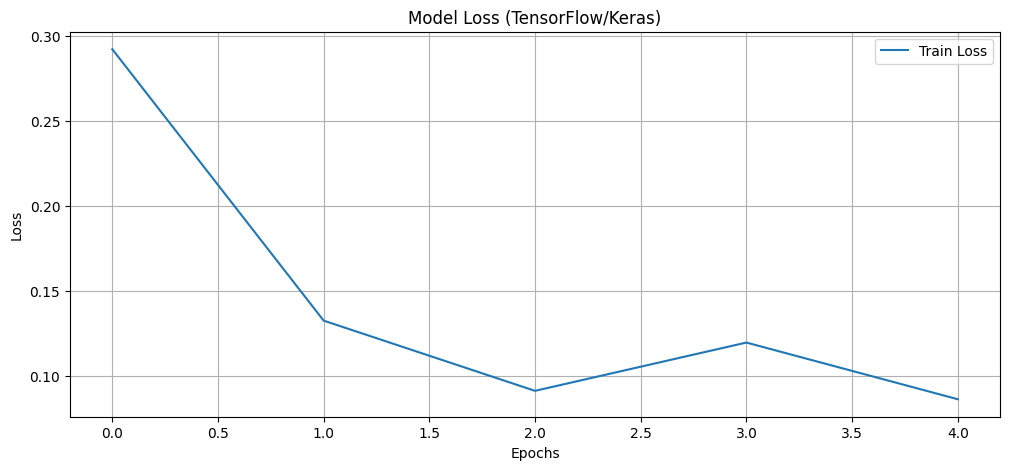

In [ ]:
import matplotlib.pyplot as plt

# Check if Keras fit history is available to plot instead of missing loss_history
try:
    # If you have loss_history defined from a PyTorch training loop, plot it:
    if 'loss_history' in globals():
        plt.figure(figsize=(12, 5))
        plt.plot(loss_history['train'], label='Train Loss')
        plt.plot(loss_history['val'], label='Val Loss')
        plt.title('Model Loss (PyTorch)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    elif 'fit' in globals() and hasattr(fit, 'history'):
        # Fallback to the Keras training loss that was run in cell e6a67789
        plt.figure(figsize=(12, 5))
        plt.plot(fit.history['loss'], label='Train Loss')
        if 'val_loss' in fit.history:
            plt.plot(fit.history['val_loss'], label='Val Loss')
        plt.title('Model Loss (TensorFlow/Keras)')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        # Mock placeholder to prevent crash
        print("No training history found. Please define 'loss_history' or run your training loop first.")
except NameError as e:
    print(f"An error occurred: {e}")

Task 10: Code for the images from val_loader, get a list of:

All predictions all_preds
The ground truth labels all_labels

In [ ]:
import torch
import torchvision.models as models

# Define the target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize a PyTorch model (e.g., MobileNetV2 matching our structure)
model = models.mobilenet_v2(pretrained=True)
# Adjust the classifier head for 2 classes (agricultural vs. non-agricultural)
model.classifier[1] = torch.nn.Linear(model.last_channel, 2)
model = model.to(device)

all_preds = []
all_labels = []

# Set PyTorch model to evaluation mode
model.eval()
with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    # Move tensors to CPU and flatten
    all_preds.extend(preds.cpu().numpy().flatten())
    all_labels.extend(labels.cpu().numpy().flatten())

print(f"Successfully collected {len(all_preds)} predictions using PyTorch.")

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 62.9MB/s]


Successfully collected 6000 predictions using PyTorch.
